# NISAR Pauli RGB and 3rd-Party SAR Filtering Tutorial

This notebook combines the Pauli RGB workflow with the shared covariance-based
third-party filtering pattern used across the SAR tutorials.

**What it shows**
1. Read a NISAR RSLC (or GSLC) quad-pol product, or synthesize a fallback.
2. Compute an unfiltered Pauli RGB reference.
3. Build the Pauli coherency matrix and run MuLoG on it.
4. Optionally run NL-SAR with a homogeneous noise image.
5. Reuse the same filter pipeline on the covariance cube for comparison.
6. Display pre/post results side-by-side in the GRDK dual-pane viewer.

**RGB mapping requested for the covariance cross-check**
- R = XX
- G = XY
- B = YY

In [14]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure local source checkouts are importable in the notebook kernel without
# machine-specific absolute paths.
def _add_repo_to_syspath(repo_name, package_dir_name):
    cwd = Path.cwd().resolve()
    for base in [cwd] + list(cwd.parents):
        candidate = base / repo_name
        if (candidate / package_dir_name).exists():
            candidate_str = str(candidate)
            if candidate_str not in sys.path:
                sys.path.insert(0, candidate_str)
            return candidate
    return None

found_grdl = _add_repo_to_syspath('grdl', 'grdl')
found_grdk = _add_repo_to_syspath('grdk', 'grdk')
found_sarf = _add_repo_to_syspath('grdl-sar-filtering', 'grdl_sar_filtering')

# If another grdl distribution was already imported, drop it and re-import from local path.
for mod_name in list(sys.modules):
    if mod_name == 'grdl' or mod_name.startswith('grdl.'):
        del sys.modules[mod_name]

import grdl
print('Using grdl from:', grdl.__file__)
print('Discovered repos:', {'grdl': found_grdl, 'grdk': found_grdk, 'grdl-sar-filtering': found_sarf})

from grdl.IO.sar.nisar import NISARReader
from grdl.IO.models.base import ImageMetadata, ChannelMetadata
from grdl.image_processing.decomposition.pauli import PauliDecomposition
from grdl.image_processing.decomposition.pol_matrix import CovarianceMatrix
from grdl_sar_filtering import create_speckle_filter

try:
    from grdk.viewers.dual_viewer import DualGeoViewer
    HAS_GRDK = True
    try:
        get_ipython().run_line_magic('gui', 'qt6')
    except (NameError, AttributeError):
        pass
except ImportError as exc:
    DualGeoViewer = None
    HAS_GRDK = False
    print(f"Warning: grdk import failed ({exc}). Falling back to matplotlib.")

def _viewer_ready_rgb(arr):
    img = np.asarray(arr)
    if img.ndim == 3 and img.shape[-1] in (1, 3, 4):
        img = np.moveaxis(img, -1, 0)
    return img

def show_dual_rgb(left, right, title, left_label='Left', right_label='Right'):
    if HAS_GRDK:
        viewer = DualGeoViewer()
        viewer.set_mode('dual')
        viewer.setWindowTitle(title)
        viewer.set_array(_viewer_ready_rgb(left), pane=0)
        viewer.set_array(_viewer_ready_rgb(right), pane=1)
        viewer.show()
        print(f"GRDK viewer launched: {title}")
        return viewer

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)
    for ax, arr, label in zip(axes, (left, right), (left_label, right_label)):
        img = np.asarray(arr)
        if img.ndim == 3 and img.shape[0] in (1, 3, 4):
            img = np.moveaxis(img, 0, -1)
        if img.ndim == 3 and img.shape[-1] == 1:
            img = img[..., 0]
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_title(label)
        ax.axis('off')
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    print(f"Matplotlib fallback shown: {title}")
    return fig

print('Imports OK')

Using grdl from: /nfs_home/jpfritz/clones/grdx/grdl/grdl/__init__.py
Discovered repos: {'grdl': PosixPath('/nfs_home/jpfritz/clones/grdx/grdl'), 'grdk': PosixPath('/nfs_home/jpfritz/clones/grdx/grdk'), 'grdl-sar-filtering': PosixPath('/nfs_home/jpfritz/clones/grdx/grdl-sar-filtering')}
Imports OK


## Configuration

Set `nisar_file` to a real NISAR RSLC file if available. If not, the next cell creates synthetic dual-pol data.

In [15]:
import logging

# Enable INFO logs so the notebook surfaces the filter and matrix-mapping steps.
logging.basicConfig(
    level=logging.INFO,
    format='[%(levelname)s] %(name)s: %(message)s',
    force=True,
 )

logging.getLogger('grdl').setLevel(logging.INFO)
logging.getLogger('grdl_sar_filtering').setLevel(logging.INFO)

print('INFO logging enabled for grdl and grdl_sar_filtering')

INFO logging enabled for grdl and grdl_sar_filtering


In [16]:
nisar_file = Path(
    '/data/sar/slc/nisar/l1_rslc/'
    '20260105T055924_20260105T055931/'
    'NISAR_L1_PR_RSLC_009_116_D_054_2005_QPDH_A_20260105T055924_20260105T055931'
    '_X05010_N_P_J_001.h5'
 )
frequency = 'A'
polarizations = 'all'
chip_size = 256   # square chip in pixels
chip_center = [9000, 10000]   # (row, col) tuple; None → auto-center
cov_window_size = 9
number_looks = 3.0

# Pauli RGB display parameters
pauli_percentile_low = 2.0
pauli_percentile_high = 98.0

# MuLoG parameters (forwarded through the filter factory)
mulog_admm_iterations = 6
mulog_denoiser = 'bm3d'

run_mulog = True
run_nlsar = False  # Set True only if nlsartoolbox is available

print(f'chip_size={chip_size}, cov_window_size={cov_window_size}, looks={number_looks}')

chip_size=256, cov_window_size=9, looks=3.0


In [17]:
def _synthetic_quad_pol_cube(rows=256, cols=256, seed=7):
    rng = np.random.default_rng(seed)

    amp_hh = rng.exponential(scale=1.0, size=(rows, cols)).astype(np.float32)
    amp_hv = rng.exponential(scale=0.6, size=(rows, cols)).astype(np.float32)
    amp_vv = rng.exponential(scale=1.0, size=(rows, cols)).astype(np.float32)

    ph_hh = rng.uniform(0.0, 2.0 * np.pi, size=(rows, cols))
    ph_hv = rng.uniform(0.0, 2.0 * np.pi, size=(rows, cols))
    ph_vv = rng.uniform(0.0, 2.0 * np.pi, size=(rows, cols))

    shh = (amp_hh * np.exp(1j * ph_hh)).astype(np.complex64)
    shv = (amp_hv * np.exp(1j * ph_hv)).astype(np.complex64)
    svh = shv.copy()
    svv = (amp_vv * np.exp(1j * ph_vv)).astype(np.complex64)

    cube = np.stack([shh, shv, svh, svv], axis=0)

    metadata = ImageMetadata(
        format='SYNTHETIC',
        rows=rows,
        cols=cols,
        bands=4,
        dtype='complex64',
        axis_order='CYX',
        channel_metadata=[
            ChannelMetadata(index=0, name='HH', polarization='HH', role='co_pol_a'),
            ChannelMetadata(index=1, name='HV', polarization='HV', role='cross_pol'),
            ChannelMetadata(index=2, name='VH', polarization='VH', role='cross_pol'),
            ChannelMetadata(index=3, name='VV', polarization='VV', role='co_pol_b'),
        ],
    )
    return cube, metadata

if nisar_file is not None and Path(nisar_file).exists():
    reader = NISARReader(nisar_file, frequency=frequency, polarizations=polarizations)
    metadata = reader.metadata

    if chip_size is None:
        cube = reader.read_full()
    else:
        if chip_center is not None:
            cr, cc = chip_center
        else:
            cr, cc = metadata.rows // 2, metadata.cols // 2
        r0 = max(0, cr - chip_size // 2)
        c0 = max(0, cc - chip_size // 2)
        r1 = min(metadata.rows, r0 + chip_size)
        c1 = min(metadata.cols, c0 + chip_size)
        cube = reader.read_chip(r0, r1, c0, c1)
    reader.close()
else:
    cube, metadata = _synthetic_quad_pol_cube(rows=chip_size or 256, cols=chip_size or 256)

available_pols = [cm.polarization.upper() for cm in metadata.channel_metadata]
pol_index = {p: i for i, p in enumerate(available_pols)}

required = {'HH', 'HV', 'VV'}
if not required.issubset(set(available_pols)):
    raise ValueError(f'Pauli decomposition requires HH, HV, VV. Found: {available_pols}')

shh = cube[pol_index['HH']].astype(np.complex64)
shv = cube[pol_index['HV']].astype(np.complex64)
svh = cube[pol_index['VH']].astype(np.complex64) if 'VH' in pol_index else shv
svv = cube[pol_index['VV']].astype(np.complex64)

svh_src = 'from VH channel' if 'VH' in pol_index else 'reciprocity S_VH = S_HV'

print(f'Cube shape   : {cube.shape}  dtype: {cube.dtype}')
print(f'Axis order   : {metadata.axis_order}')
print(f'Polarizations: {available_pols}')
print(f'S_HH shape   : {shh.shape}')
print(f'S_HV shape   : {shv.shape}')
print(f'S_VH source  : {svh_src}')
print(f'S_VV shape   : {svv.shape}')

[INFO] grdl.IO.sar.nisar: Loaded NISAR RSLC NISAR_L1_PR_RSLC_009_116_D_054_2005_QPDH_A_20260105T055924_20260105T055931_X05010_N_P_J_001.h5 (12160 x 26124) freq=A pol=HV,VV,VH,HH


Cube shape   : (4, 256, 256)  dtype: complex64
Axis order   : CYX
Polarizations: ['HV', 'VV', 'VH', 'HH']
S_HH shape   : (256, 256)
S_HV shape   : (256, 256)
S_VH source  : from VH channel
S_VV shape   : (256, 256)


## Pauli RGB and MuLoG

This section mirrors the filtering notebook style, but works in the Pauli basis so the
MuLoG output can be compared directly against the unfiltered Pauli RGB. The same
filter factory is used here, which keeps NL-SAR easy to add later.

In [18]:
pauli = PauliDecomposition()

components = pauli.decompose(shh, shv, svh, svv)
print(f"surface      shape: {components['surface'].shape}  dtype: {components['surface'].dtype}")
print(f"double_bounce shape: {components['double_bounce'].shape}")
print(f"volume       shape: {components['volume'].shape}")

rgb_unfiltered, _meta = pauli.to_rgb(
    components,
    representation='db',
    percentile_low=pauli_percentile_low,
    percentile_high=pauli_percentile_high,
)
rgb_unfiltered_u8 = (np.clip(rgb_unfiltered.transpose(1, 2, 0), 0.0, 1.0) * 255).astype(np.uint8)

t_vec = np.stack(
    [components['surface'], components['double_bounce'], components['volume']],
    axis=0,
 ).astype(np.complex64)

pauli_T = np.einsum('iyx,jyx->yxij', t_vec, np.conj(t_vec), optimize=True).astype(np.complex64)
print(f"Pauli coherency matrix T: {pauli_T.shape}  dtype={pauli_T.dtype}")
print(f"Memory footprint: {pauli_T.nbytes / 1e6:.1f} MB")

def _percentile_stretch(arr: np.ndarray, plo: float, phi: float) -> np.ndarray:
    lo, hi = np.percentile(arr, [plo, phi])
    return np.clip((arr - lo) / max(hi - lo, 1e-8), 0.0, 1.0).astype(np.float32)

def pauli_matrix_to_rgb(matrix: np.ndarray) -> np.ndarray:
    surface_pwr = np.real(matrix[..., 0, 0])
    double_bounce_pwr = np.real(matrix[..., 1, 1])
    volume_pwr = np.real(matrix[..., 2, 2])

    eps = 1e-10
    surface_db = 10.0 * np.log10(surface_pwr + eps)
    double_bounce_db = 10.0 * np.log10(double_bounce_pwr + eps)
    volume_db = 10.0 * np.log10(volume_pwr + eps)

    r = _percentile_stretch(double_bounce_db, pauli_percentile_low, pauli_percentile_high)
    g = _percentile_stretch(volume_db, pauli_percentile_low, pauli_percentile_high)
    b = _percentile_stretch(surface_db, pauli_percentile_low, pauli_percentile_high)
    return np.stack([r, g, b], axis=-1)

pauli_results = {'pre': pauli_T}

if run_mulog:
    pauli_mulog = create_speckle_filter(
        'mulog',
        number_looks=number_looks,
        admm_iterations=mulog_admm_iterations,
        denoiser_name=mulog_denoiser,
    )
    pauli_results['mulog'] = pauli_mulog.apply(pauli_T)
    print('MuLoG complete for Pauli coherency:', pauli_results['mulog'].shape)

if run_nlsar:
    pauli_nlsar = create_speckle_filter('nlsar', number_looks=number_looks)

    m, n, d, _ = pauli_T.shape
    mean_power = float(np.median(np.real(np.trace(pauli_T, axis1=-2, axis2=-1))))
    noise_image = np.zeros((m, n, d, d), dtype=np.complex64)
    for i in range(d):
        noise_image[..., i, i] = mean_power / max(d, 1)

    pauli_results['nlsar'] = pauli_nlsar.apply(pauli_T, noise_image=noise_image)
    print('NL-SAR complete for Pauli coherency:', pauli_results['nlsar'].shape)

pauli_rgb_results = {k: pauli_matrix_to_rgb(v) for k, v in pauli_results.items()}
post_key = 'mulog' if 'mulog' in pauli_rgb_results else ('nlsar' if 'nlsar' in pauli_rgb_results else 'pre')

_viewer = show_dual_rgb(
    rgb_unfiltered_u8,
    pauli_rgb_results[post_key],
    f'NISAR Pauli RGB — Unfiltered (left) | {post_key.upper()}-filtered (right)',
    left_label='Unfiltered Pauli RGB',
    right_label=f'{post_key.upper()}-filtered Pauli RGB',
)

print('Pauli viewer launched — GRDK if available, otherwise matplotlib fallback shown.')

[INFO] grdl.image_processing.decomposition.pauli: Pauli decomposition: shape (256, 256), 4 channels, dtype complex64, window_size=1


surface      shape: (256, 256)  dtype: complex64
double_bounce shape: (256, 256)
volume       shape: (256, 256)
Pauli coherency matrix T: (256, 256, 3, 3)  dtype=complex64
Memory footprint: 4.7 MB


[INFO] grdk.dual_viewer: DualGeoViewer: mode -> dual
[INFO] grdk.image_canvas: ImageCanvas.set_array: shape=(3, 256, 256) dtype=uint8
[INFO] grdk.dual_viewer: SyncController: geolocations updated, left=None, right=None, overlap=False
[INFO] grdk.image_canvas: ImageCanvas.set_array: shape=(3, 256, 256) dtype=float32
[INFO] grdk.dual_viewer: SyncController: geolocations updated, left=None, right=None, overlap=False


MuLoG complete for Pauli coherency: (256, 256, 3, 3)
GRDK viewer launched: NISAR Pauli RGB — Unfiltered (left) | MULOG-filtered (right)
Pauli viewer launched — GRDK if available, otherwise matplotlib fallback shown.


## Covariance Matrix

`CovarianceMatrix.execute` returns **CCYX**: `(N, N, rows, cols)`.
The filters expect **YXCC**: `(rows, cols, N, N)`.

In [19]:
cmat = CovarianceMatrix(window_size=cov_window_size)
cov_ccyx, cov_meta = cmat.execute(metadata, cube)
cov_yxcc = np.transpose(cov_ccyx, (2, 3, 0, 1))

print('cov_ccyx shape:', cov_ccyx.shape)
print('cov_yxcc shape:', cov_yxcc.shape)

[INFO] grdl.image_processing.decomposition.pol_matrix: pol_matrix channel extraction: strategy=token_canonical axis_order=CYX n=4 input=['idx=0 name=A_HV pol=HV role=measurement', 'idx=1 name=A_VV pol=VV role=measurement', 'idx=2 name=A_VH pol=VH role=measurement', 'idx=3 name=A_HH pol=HH role=measurement'] resolved=['co_pol_a(HH)<-idx=3', 'cross_pol<-idx=0', 'cross_pol_2<-idx=2', 'co_pol_b(VV)<-idx=1']
[INFO] grdl.image_processing.decomposition.pol_matrix: CovarianceMatrix execute: input_channels=4 window_size=9
[INFO] grdl.image_processing.decomposition.pol_matrix: CovarianceMatrix execute: output_matrix=3x3 axis_order=CCYX


cov_ccyx shape: (3, 3, 256, 256)
cov_yxcc shape: (256, 256, 3, 3)


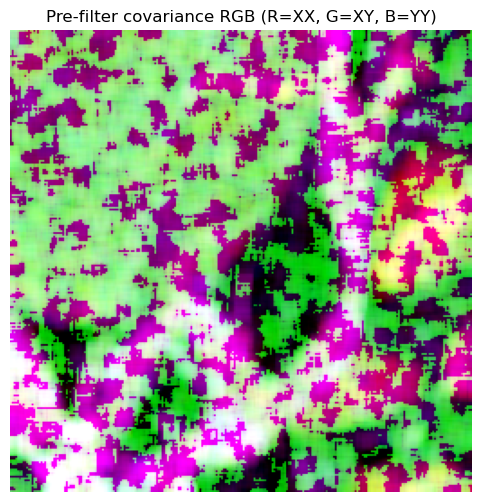

In [20]:
def cov_to_rgb(cov):
    """Map covariance to RGB with R=XX, G=XY, B=YY."""
    # cov shape: (rows, cols, N, N)
    xx = np.real(cov[..., 0, 0])
    xy = np.real(cov[..., 0, 1])
    yy = np.real(cov[..., -1, -1])

    rgb = np.stack([xx, xy, yy], axis=-1).astype(np.float32)

    # SAR-friendly display scaling
    rgb = np.log10(np.maximum(rgb, 1e-8))

    out = np.empty_like(rgb, dtype=np.float32)
    for b in range(3):
        lo, hi = np.percentile(rgb[..., b], [2.0, 98.0])
        out[..., b] = np.clip((rgb[..., b] - lo) / max(hi - lo, 1e-8), 0.0, 1.0)
    return out

rgb_pre = cov_to_rgb(cov_yxcc)

plt.figure(figsize=(6, 6))
plt.imshow(rgb_pre)
plt.title('Pre-filter covariance RGB (R=XX, G=XY, B=YY)')
plt.axis('off')
plt.show()

## Speckle Filtering

Apply MuLoG and optionally NL-SAR on the YXCC covariance cube.

In [ ]:
results = {'pre': cov_yxcc}

if run_mulog:
    mulog = create_speckle_filter('mulog', number_looks=number_looks)
    results['mulog'] = mulog.apply(cov_yxcc)
    print('MuLoG complete:', results['mulog'].shape)

if run_nlsar:
    nlsar = create_speckle_filter('nlsar', number_looks=number_looks)

    # Build a homogeneous noise covariance image for NL-SAR statistics.
    m, n, d, _ = cov_yxcc.shape
    mean_power = float(np.median(np.real(np.trace(cov_yxcc, axis1=-2, axis2=-1))))
    noise_image = np.zeros((m, n, d, d), dtype=np.complex64)
    for i in range(d):
        noise_image[..., i, i] = mean_power / max(d, 1)

    results['nlsar'] = nlsar.apply(cov_yxcc, noise_image=noise_image)
    print('NL-SAR complete:', results['nlsar'].shape)

In [ ]:
rgb_results = {k: cov_to_rgb(v) for k, v in results.items()}

ncols = len(rgb_results)
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 6))
if ncols == 1:
    axes = [axes]

for ax, (name, img) in zip(axes, rgb_results.items()):
    ax.imshow(img)
    ax.set_title(name.upper())
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def span(cov):
    return np.real(np.trace(cov, axis1=-2, axis2=-1))

span_pre = span(results['pre'])
print('Span pre mean/std:', float(span_pre.mean()), float(span_pre.std()))

for key in results:
    if key == 'pre':
        continue
    sp = span(results[key])
    print(f'Span {key} mean/std:', float(sp.mean()), float(sp.std()))

## GRDK Side-by-Side Viewer

Left pane shows pre-filter RGB and right pane shows selected post-filter RGB.

In [ ]:
post_key = 'mulog' if 'mulog' in rgb_results else ('nlsar' if 'nlsar' in rgb_results else 'pre')

viewer = show_dual_rgb(
    rgb_results['pre'],
    rgb_results[post_key],
    f'Covariance RGB — pre (L) vs {post_key} (R)',
    left_label='Pre-filter covariance RGB',
    right_label=f'{post_key.upper()} covariance RGB',
)

print('Viewer launched with panes: pre vs', post_key)

## Notes

- The first half of the notebook works in the Pauli basis so the MuLoG output can be compared directly against the unfiltered Pauli RGB.
- The second half reuses the same 3rd-party filter pipeline on the covariance cube for a shared GRDL-style reference.
- `run_nlsar` requires a built `nlsartoolbox` plus a homogeneous `noise_image`.
- The synthetic fallback is quad-pol so both sections run without a local NISAR file.